# Carregando o Dataset

In [1]:
import pandas as pd

url ="https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Normalizando os dados

In [2]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [3]:
import numpy as np
df["Amount_log"] = np.log1p(df["Amount"]) 

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])


In [5]:
from sklearn.model_selection import train_test_split
x = df.drop("Class", axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
x, y, stratify=y, test_size=0.3, random_state=42
) 

# Verificando e removendo valores nulos e outliers

In [6]:
df.isnull().sum()

Time             0
V1               0
V2               0
V3               0
V4               0
V5               0
V6               0
V7               0
V8               0
V9               0
V10              0
V11              0
V12              0
V13              0
V14              0
V15              0
V16              0
V17              0
V18              0
V19              0
V20              0
V21              0
V22              0
V23              0
V24              0
V25              0
V26              0
V27              0
V28              0
Amount           0
Class            0
Amount_log       0
Amount_scaled    0
dtype: int64

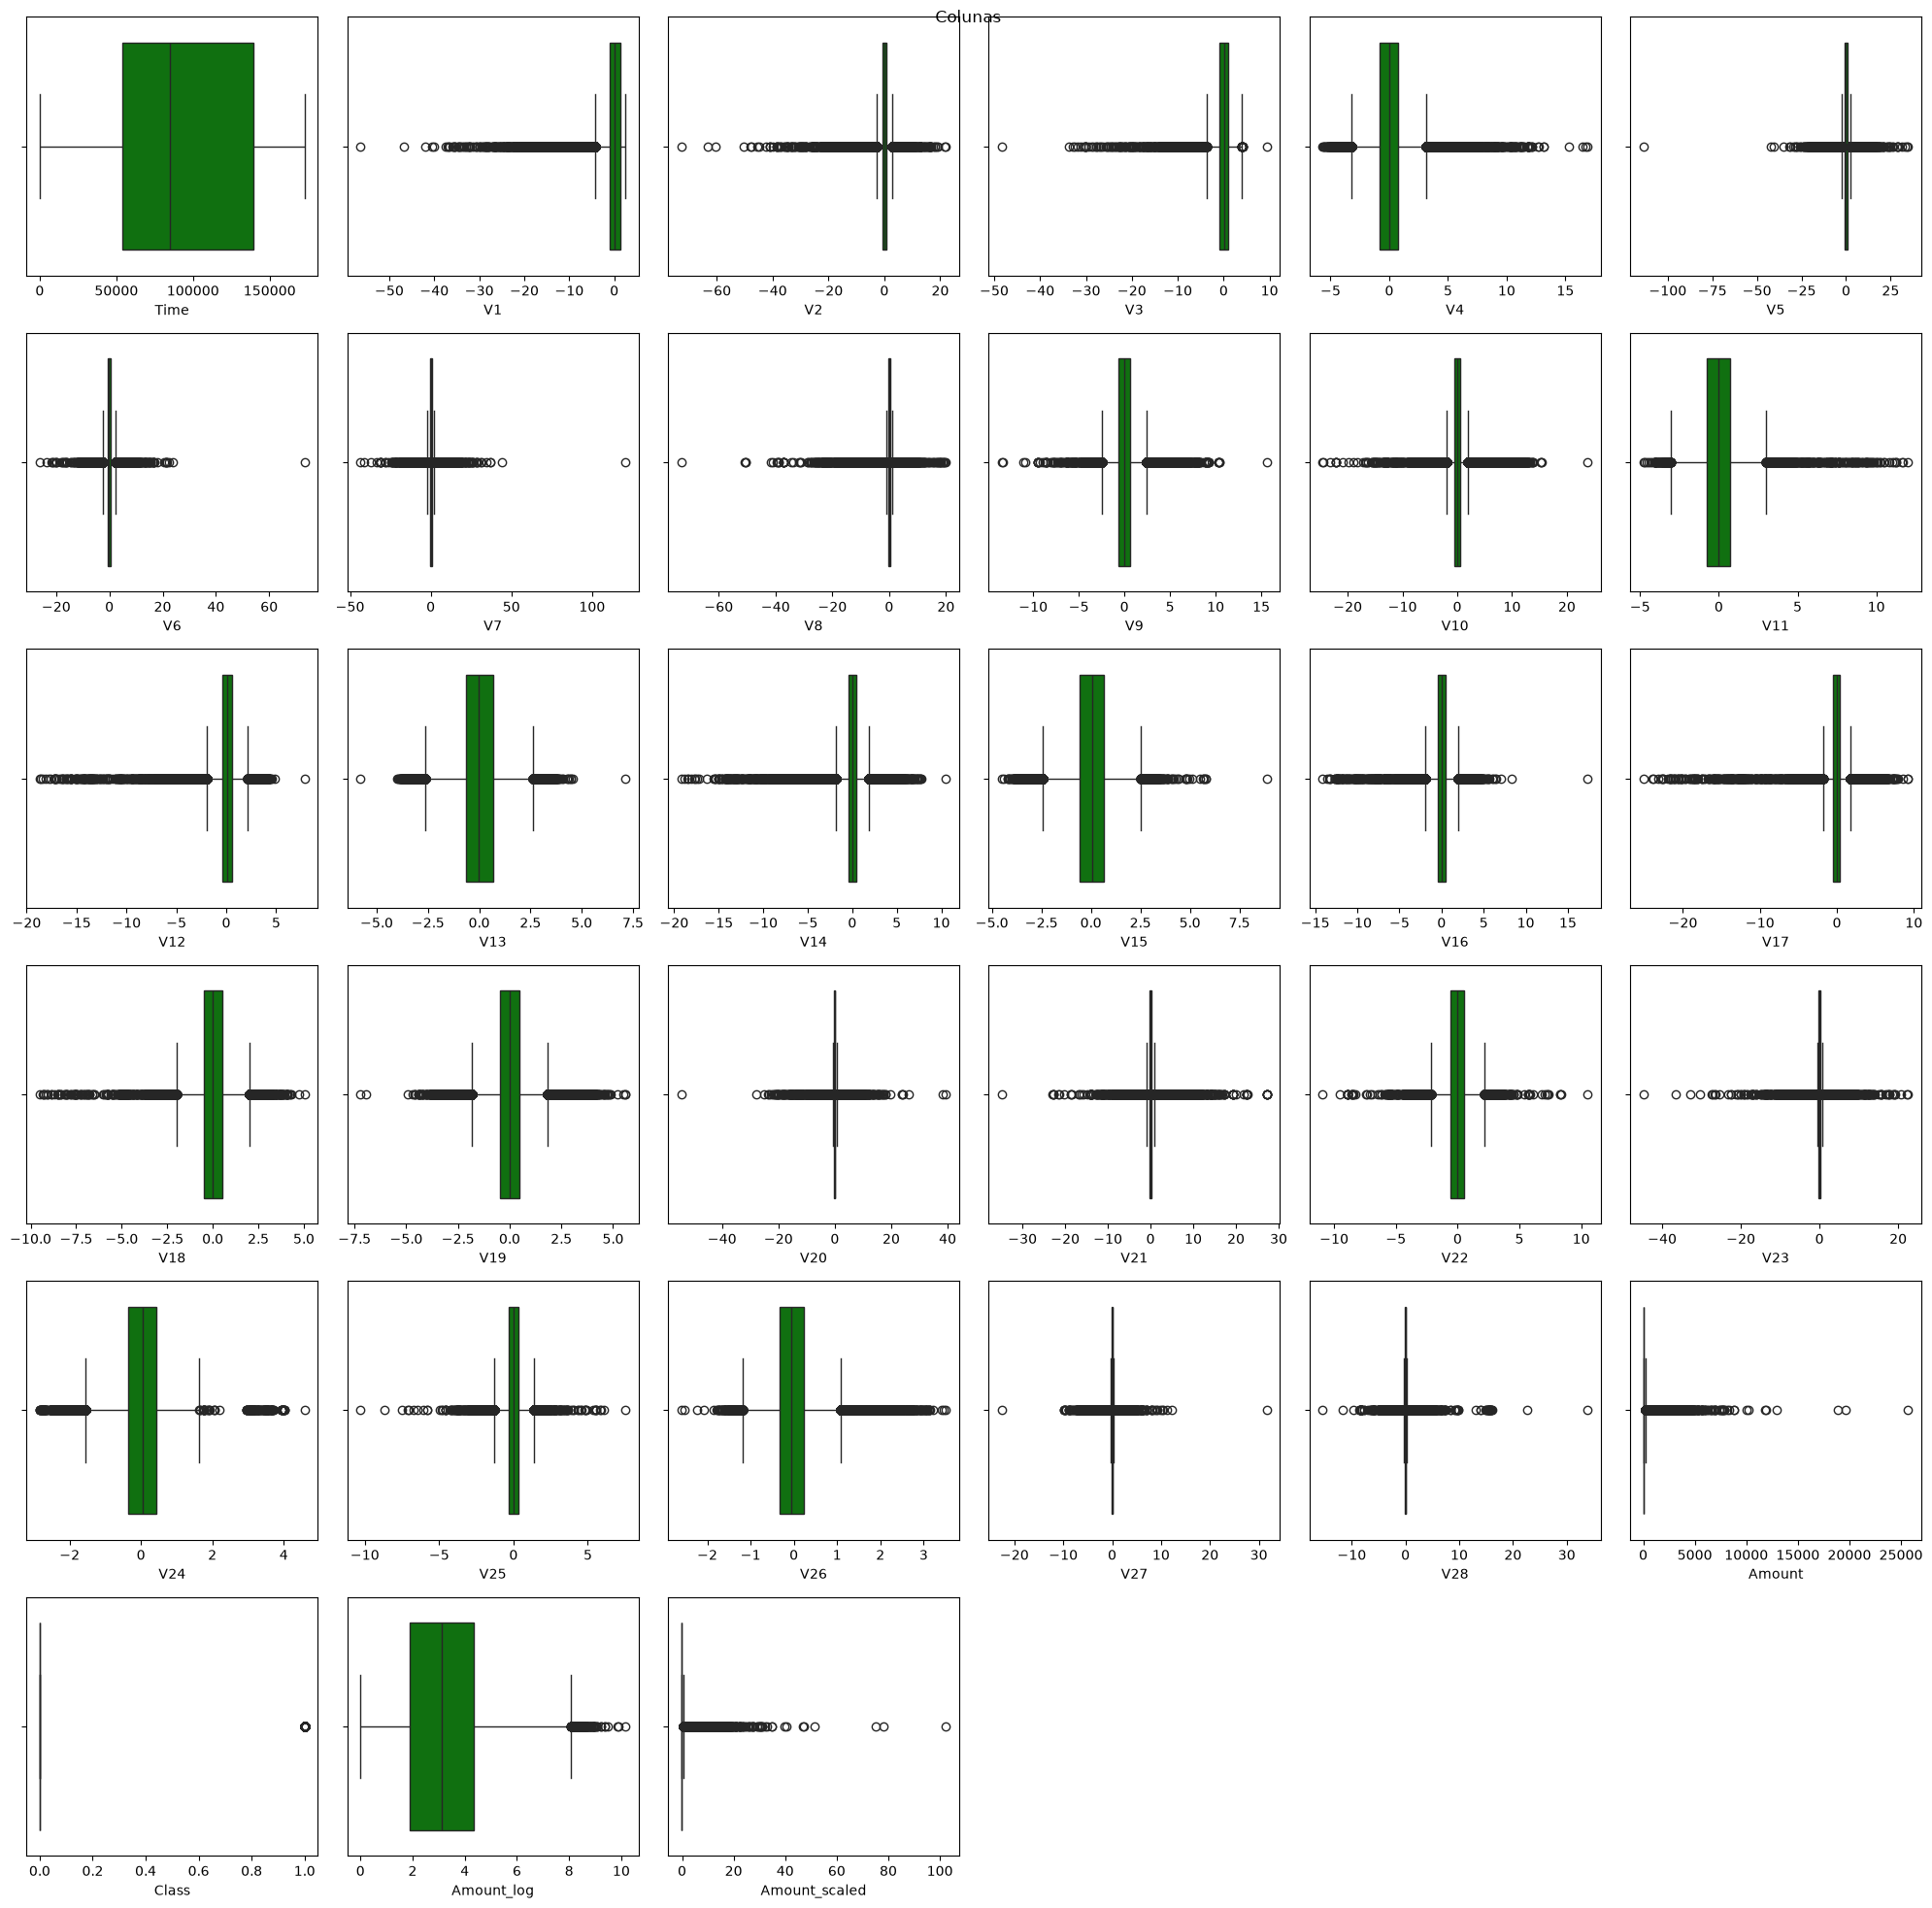

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Utilizando box plot para verificar se há anomalias

plt.figure(figsize=(20,20))

for i, col in enumerate(df.columns):
    axs = plt.subplot(6,6, i+1)
    sns.boxplot(data=df, x=col, color='green')
plt.suptitle('Colunas')
plt.tight_layout()

In [8]:
for col in df.columns:
    if col in ['Class']: #ignorando as anomalias encontrados em Class porque são importantes
        continue
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
            
    IQR = q3 - q1
        
    lower_array = q1 - 1.5 * IQR
    upper_array = q3 + 1.5 * IQR
        
    media = df[col].median()
    outliers = (df[col] < lower_array) | (df[col] > upper_array)
    df.loc[outliers, col] = media

    


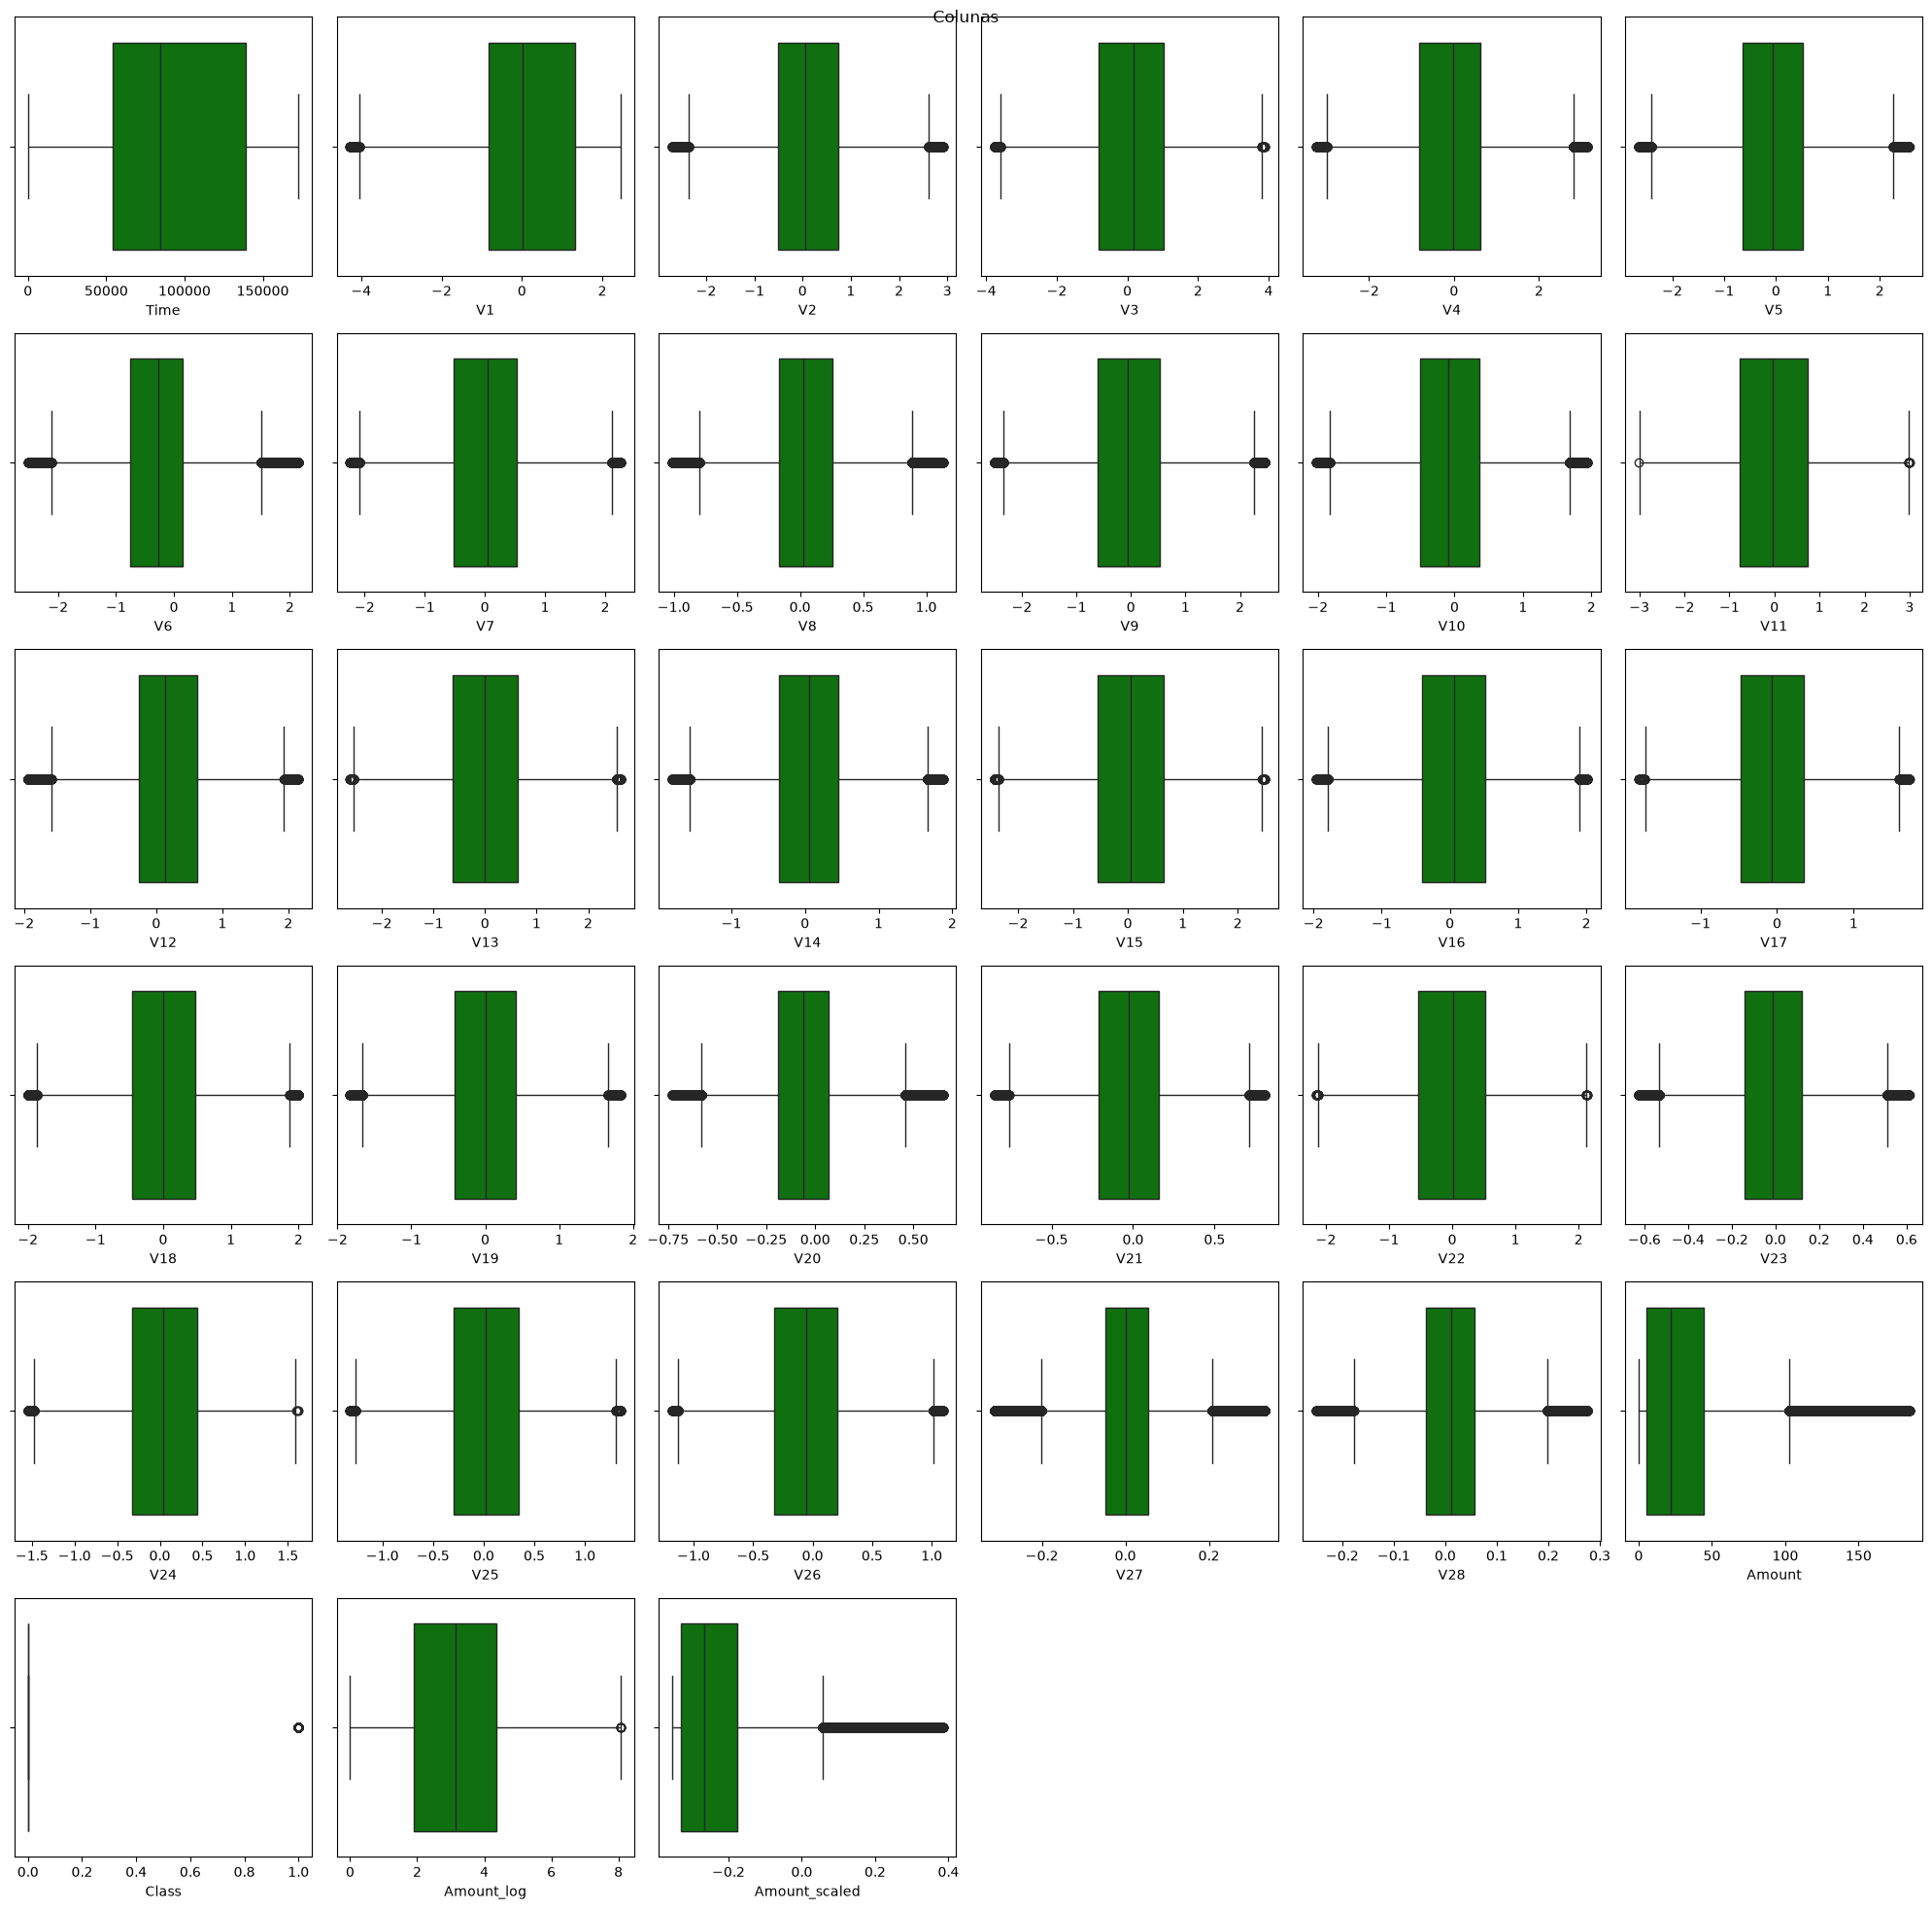

In [9]:
plt.figure(figsize=(20,20))

for i, col in enumerate(df.columns):
    axs = plt.subplot(6,6, i+1)
    sns.boxplot(data=df, x=col, color='green')
plt.suptitle('Colunas')
plt.tight_layout()

# Treinamento de Modelos

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000) 

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.68      0.75       148

    accuracy                           1.00     85443
   macro avg       0.92      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


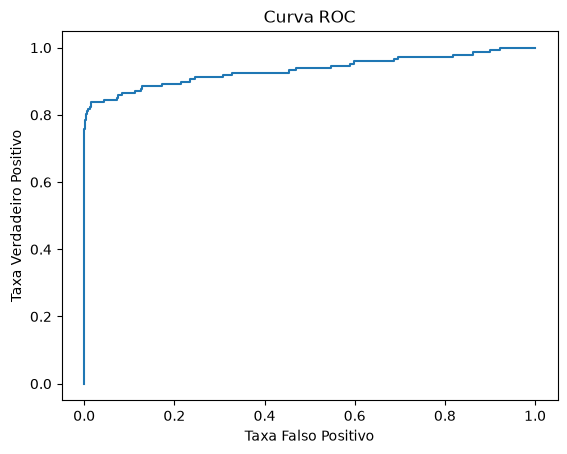

AUC: 0.9339226500080009


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title('Curva ROC')
plt.xlabel('Taxa Falso Positivo')
plt.ylabel('Taxa Verdadeiro Positivo')
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

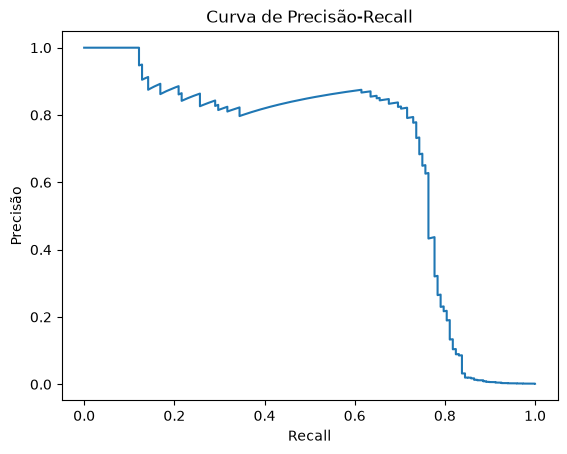

In [12]:
from sklearn.metrics import precision_recall_curve

precision,  recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Curva de Precisão-Recall")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.show()


In [13]:
from imblearn.over_sampling import SMOTE

# utilizando-se apenas o oversampling dado a preferência em melhorar o recall e não a precisão

sm = SMOTE(sampling_strategy='minority', random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(x_train, y_train)

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
n_estimators=50,
max_depth=20,
class_weight="balanced",
n_jobs=-1,
random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.77      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



In [15]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.80      0.72      0.75       148

    accuracy                           1.00     85443
   macro avg       0.90      0.86      0.88     85443
weighted avg       1.00      1.00      1.00     85443



In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
"max_depth": [10, 20],
"n_estimators": [50, 100],
}

grid = GridSearchCV(
estimator=RandomForestClassifier(random_state=42), 
param_grid=param_grid,
scoring="recall",
cv=3
)
grid.fit(x_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 20, 'n_estimators': 100}


In [17]:
rf = RandomForestClassifier(
n_estimators=100,
max_depth=20,
class_weight="balanced",
n_jobs=-1,
random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.92      0.76      0.83       148

    accuracy                           1.00     85443
   macro avg       0.96      0.88      0.91     85443
weighted avg       1.00      1.00      1.00     85443



In [18]:
from sklearn.tree import DecisionTreeClassifier

classifier=DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
classifier.fit(x_train,y_train)
y_pred_dtc=classifier.predict(x_test)

print(classification_report(y_test, y_pred_dtc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.78      0.73      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.86      0.88     85443
weighted avg       1.00      1.00      1.00     85443



In [19]:
from sklearn.naive_bayes import GaussianNB

classifier=GaussianNB()
classifier.fit(x_train,y_train)
y_pred_nb =classifier.predict(x_test)

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     85295
           1       0.14      0.62      0.23       148

    accuracy                           0.99     85443
   macro avg       0.57      0.81      0.61     85443
weighted avg       1.00      0.99      1.00     85443



In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
scale_pos_weight=10,
eval_metric="logloss"
)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

print(classification_report(y_test,y_pred_xgb))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



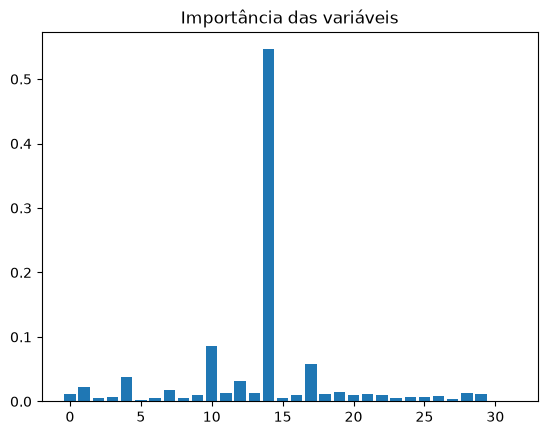

In [21]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()


In [22]:
param_grid = {
"max_depth": [3, 5],
"n_estimators": [50, 100],
'learning_rate': [0.1, 0.01, 0.001],
}

grid = GridSearchCV(
XGBClassifier(eval_metric="logloss"),
param_grid,
scoring="recall",
cv=3
)
grid.fit(x_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [23]:
xgb = XGBClassifier(
scale_pos_weight=10,
n_estimators=100,
max_depth = 10,
eval_metric="logloss"
)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



# Limiar de Decisão e Demonstração SHAP

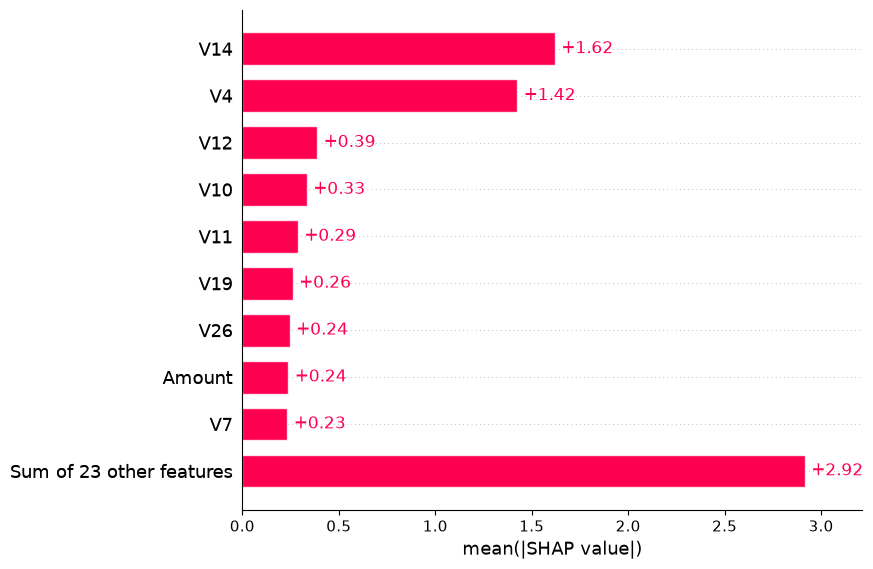

In [24]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])
shap.plots.bar(shap_values)